<p align="center">
  <br/>
    <a href="https://pdf-redaction.com/" target="_blank"><img alt="PDF Redaction"
    src="https://pdf-redaction.com/images/pdf-redaction-logo.svg" width="450" style="max-width: 100%;"></a>
  <br/>
</p>

<p align="center">
    <i>Secure Your PDFs with AI-powered Redaction</i>
</p>

<p align="center">
    <a target="_blank" href="https://colab.research.google.com/github/StabRise/pdf-redaction-api/blob/main/jupyter/PDF-Redaction-API-base64-rotated.ipynb">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://github.com/stabrise/spark-pdf/blob/main/LICENSE"><img alt="GitHub" src="https://img.shields.io/github/license/stabrise/spark-pdf.svg?color=blue"></a>
    <a href="https://stabrise.com"><img alt="StabRise" src="https://img.shields.io/badge/powered%20by-StabRise-orange.svg?style=flat&colorA=E1523D&colorB=blue"/>
    </a>
</p>

# Example of using PDF Redaction API for redact documents with rotated/vertical text

**Source**: [https://github.com/StabRise/pdf-redaction-api](https://github.com/StabRise/pdf-redaction-api)

[Swagger API documentation](https://api.pdf-redaction.com/api/docs)

Documentation: [https://pdf-redaction.com/docs/api/](https://pdf-redaction.com/docs/api/)

Self-Hosted PDF Redaction API:[https://pdf-redaction.com/docs/api-self-hosted/](https://pdf-redaction.com/docs/api-self-hosted/)

Web UI: [https://pdf-redaction.com](https://pdf-redaction.com)

For generate API Key please go to the: [https://pdf-redaction.com/apikeys/](https://pdf-redaction.com/apikeys/)

For check usage: [https://pdf-redaction.com/apikeys/usage/](https://pdf-redaction.com/apikeys/usage/)

Put API Key to the env variable `PDF_REDACTION_API_KEY` or to `.env` file.

## Limitations for free version
* 10 page per request
* 100 Free requests per month
* 5 requests per minute

## Installing dependencies for displaying PDF files

In [ ]:
%%bash
if [[ "$OSTYPE" == "linux-gnu"* ]]; then
    echo "Detected Linux. Installing poppler-utils..."
    apt-get install -y poppler-utils wget
elif [[ "$OSTYPE" == "darwin"* ]]; then
    echo "Detected macOS. Installing poppler..."
    brew install poppler wget
else
    echo "Unsupported OS: $OSTYPE"
fi

In [ ]:
%pip install requests pdf2image pillow python-dotenv

## Downloading example PDF files

In [1]:
!wget https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/SampleWithRotatedText.pdf

--2026-03-22 16:37:40--  https://raw.githubusercontent.com/StabRise/pdf-redaction-api/refs/heads/main/examples/pdfs/SampleWithRotatedText.pdf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 148117 (145K) [application/octet-stream]
Saving to: ‘SampleWithRotatedText.pdf’

SampleWithRotatedTe 100%[===================>] 144.65K  --.-KB/s    in 0.05s   

2026-03-22 16:37:40 (2.64 MB/s) - ‘SampleWithRotatedText.pdf’ saved [148117/148117]



# Display original PDF

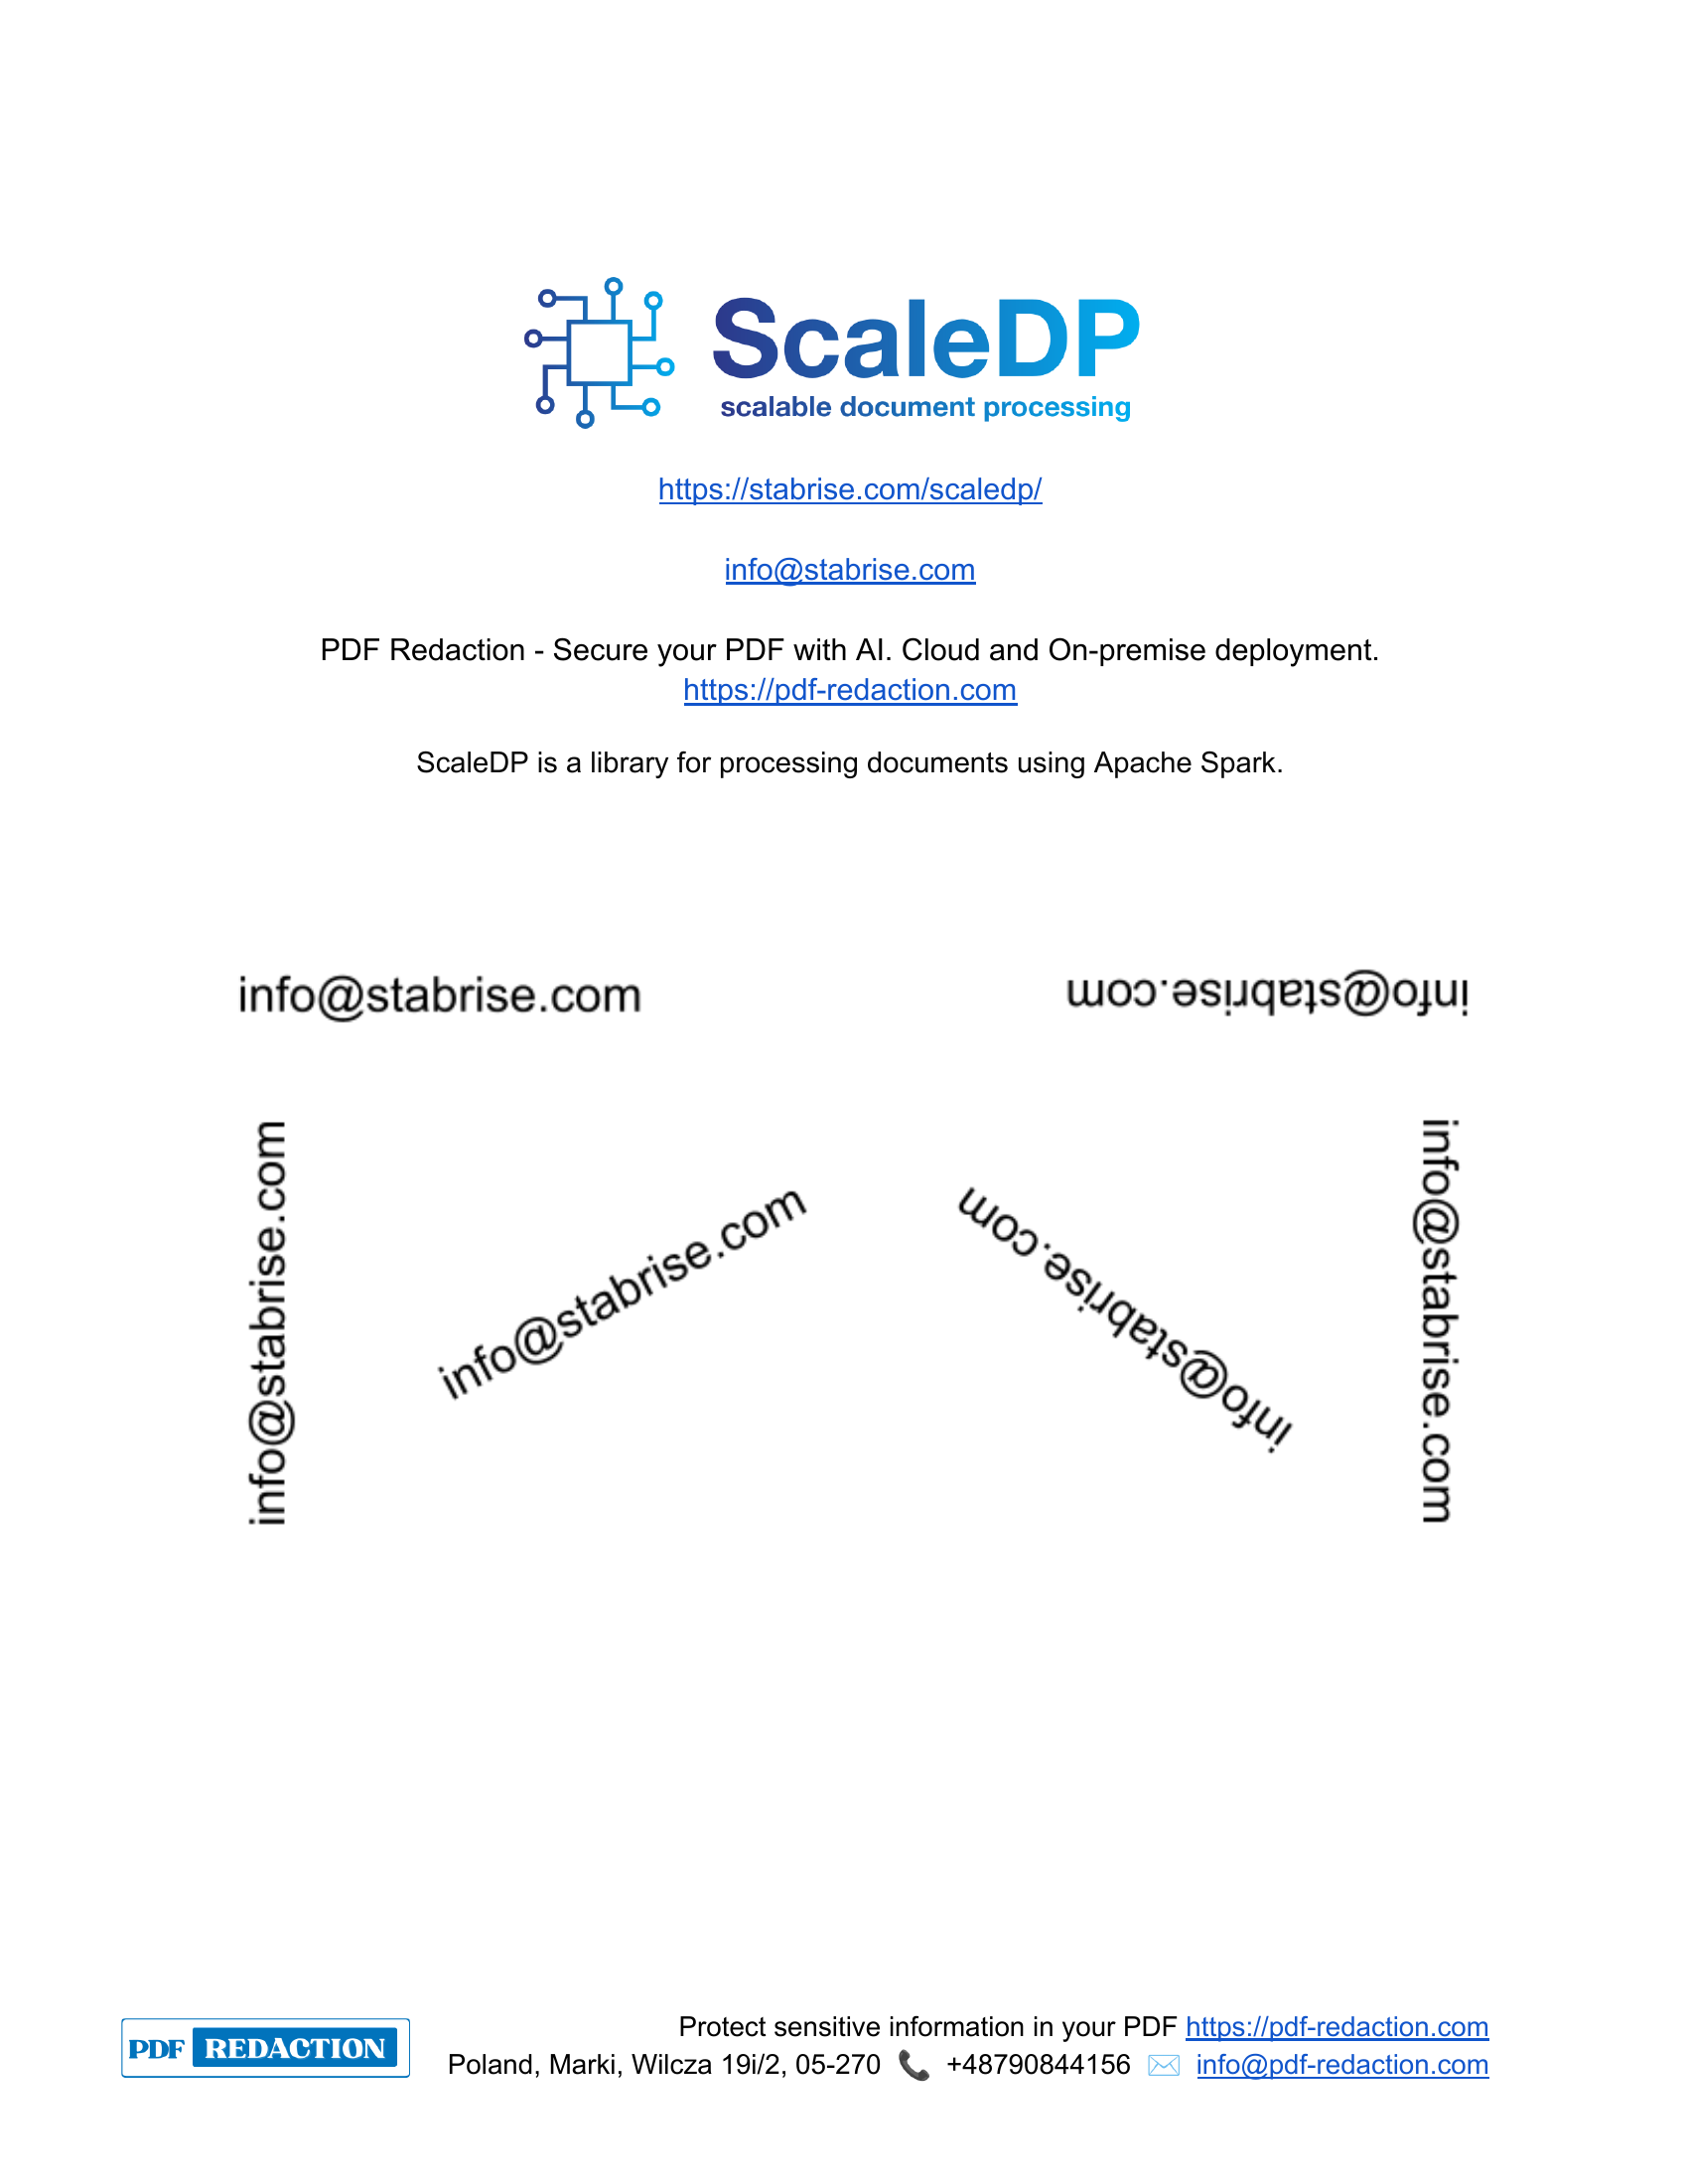

In [2]:
from pdf2image import convert_from_path
from IPython.display import display

# File path to your PDF (replace with your actual file path)
file_path = "../../scaledp/tests/testresources/pdfs/SampleWithRotatedText.pdf"
# or use local file from example folder
#file_path = "../examples/pdfs/SampleWithRotatedText.pdf"


def display_pdf(pdf_path):
    """Display first page of the pdf file"""
    # Convert first page of PDF to image
    pages = convert_from_path(pdf_path, first_page=1, last_page=1)  # returns a list of PIL Images

    # Display first page
    display(pages[0])

display_pdf(file_path)

# Redact PDF using API

In [3]:
import requests
from pathlib import Path
import base64
import json
import os
from dotenv import load_dotenv

load_dotenv()

pdf_redaction_api_base_url = os.environ.get(
    "PDF_REDACTION_API_BASE_URL",
    "https://api.pdf-redaction.com/api")

pdf_redaction_api_key = os.environ.get("PDF_REDACTION_API_KEY")

# Assemble full URL
pdf_redaction_api_url = f"{pdf_redaction_api_base_url}/anonymize/pdf"

# Define the tags to redact, if not specified all tags will be redacted
tags = [
    "DATE",
    "PERSON_NAME",
    "ORGANIZATION",
    "LOCATION",
    "EMAIL",
    "PHONE",
    "ID",
    "ACCOUNT",
    "ZIP_CODE",
    "ADDRESS",
    "IP",
    "URL",
    "SSN",
    "DRIVER_LICENSE",
    "PASSPORT",
    "AGE",
    "CREDIT_CARD",
]

# Create output directory path
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist

# Compute output file name based on input file name
input_file = Path(file_path)
output_file_path = output_dir / f"redacted_{input_file.name}"

headers = {
    "accept": "application/pdf",
    "X-API-Key": pdf_redaction_api_key,
}

# Read the PDF file and send it to the API
with open(file_path, "rb") as f:
    pdf_decoded = base64.b64encode(f.read()).decode("utf-8")
    response = requests.post(pdf_redaction_api_url,
                             headers=headers,
                             json={
                                 "pdf": pdf_decoded,
                                 "tags": tags,
                                 "rotated_text": True,
                                 "force_ocr": True
                             })

print("Status code:", response.status_code)

# Save the redacted PDF to a file
if response.status_code == 200:
    print(response)
    result = response.json()

    pdf_data = result["pdf"].encode()
    content = base64.b64decode(pdf_data)

    with open(output_file_path, "wb") as out:
        out.write(content)
    print(f"Redacted PDF saved as '{output_file_path}'.")
else:
    print("Error:", response.json())

Status code: 200
<Response [200]>
Redacted PDF saved as 'output/redacted_SampleWithRotatedText.pdf'.


## Display processing time

In [4]:
print(json.dumps(result['processing_time'], indent=4))

{
    "total": 5.4975,
    "stages": {
        "PdfDataToSingleImage": 0.2859,
        "DBNetOnnxDetector": 0.7288,
        "TextRecognizer": 0.6479,
        "Ocr": 0.8781,
        "Ner": 2.5646,
        "ImageDrawBoxes": 0.2653,
        "SingleImageToPdf": 0.1266
    }
}


## Display detected PII

In [5]:
print(json.dumps(result['detected_pii'], indent=4))

{
    "path": "memory",
    "entities": [
        {
            "entity_group": "ORGANIZATION",
            "score": 0.0,
            "word": "info@stabrise.com\n",
            "start": 0,
            "end": 0,
            "boxes": [
                {
                    "text": "info@stabrise.com\n",
                    "score": 1.0,
                    "x": 1363,
                    "y": 1927,
                    "width": 671,
                    "height": 121,
                    "angle": 37.67273712158203
                }
            ]
        },
        {
            "entity_group": "URL",
            "score": 0.0,
            "word": "",
            "start": 0,
            "end": 0,
            "boxes": []
        },
        {
            "entity_group": "EMAIL",
            "score": 0.0,
            "word": "",
            "start": 0,
            "end": 0,
            "boxes": []
        },
        {
            "entity_group": "URL",
            "score": 0.0,
            "word

## Display redacted PDF

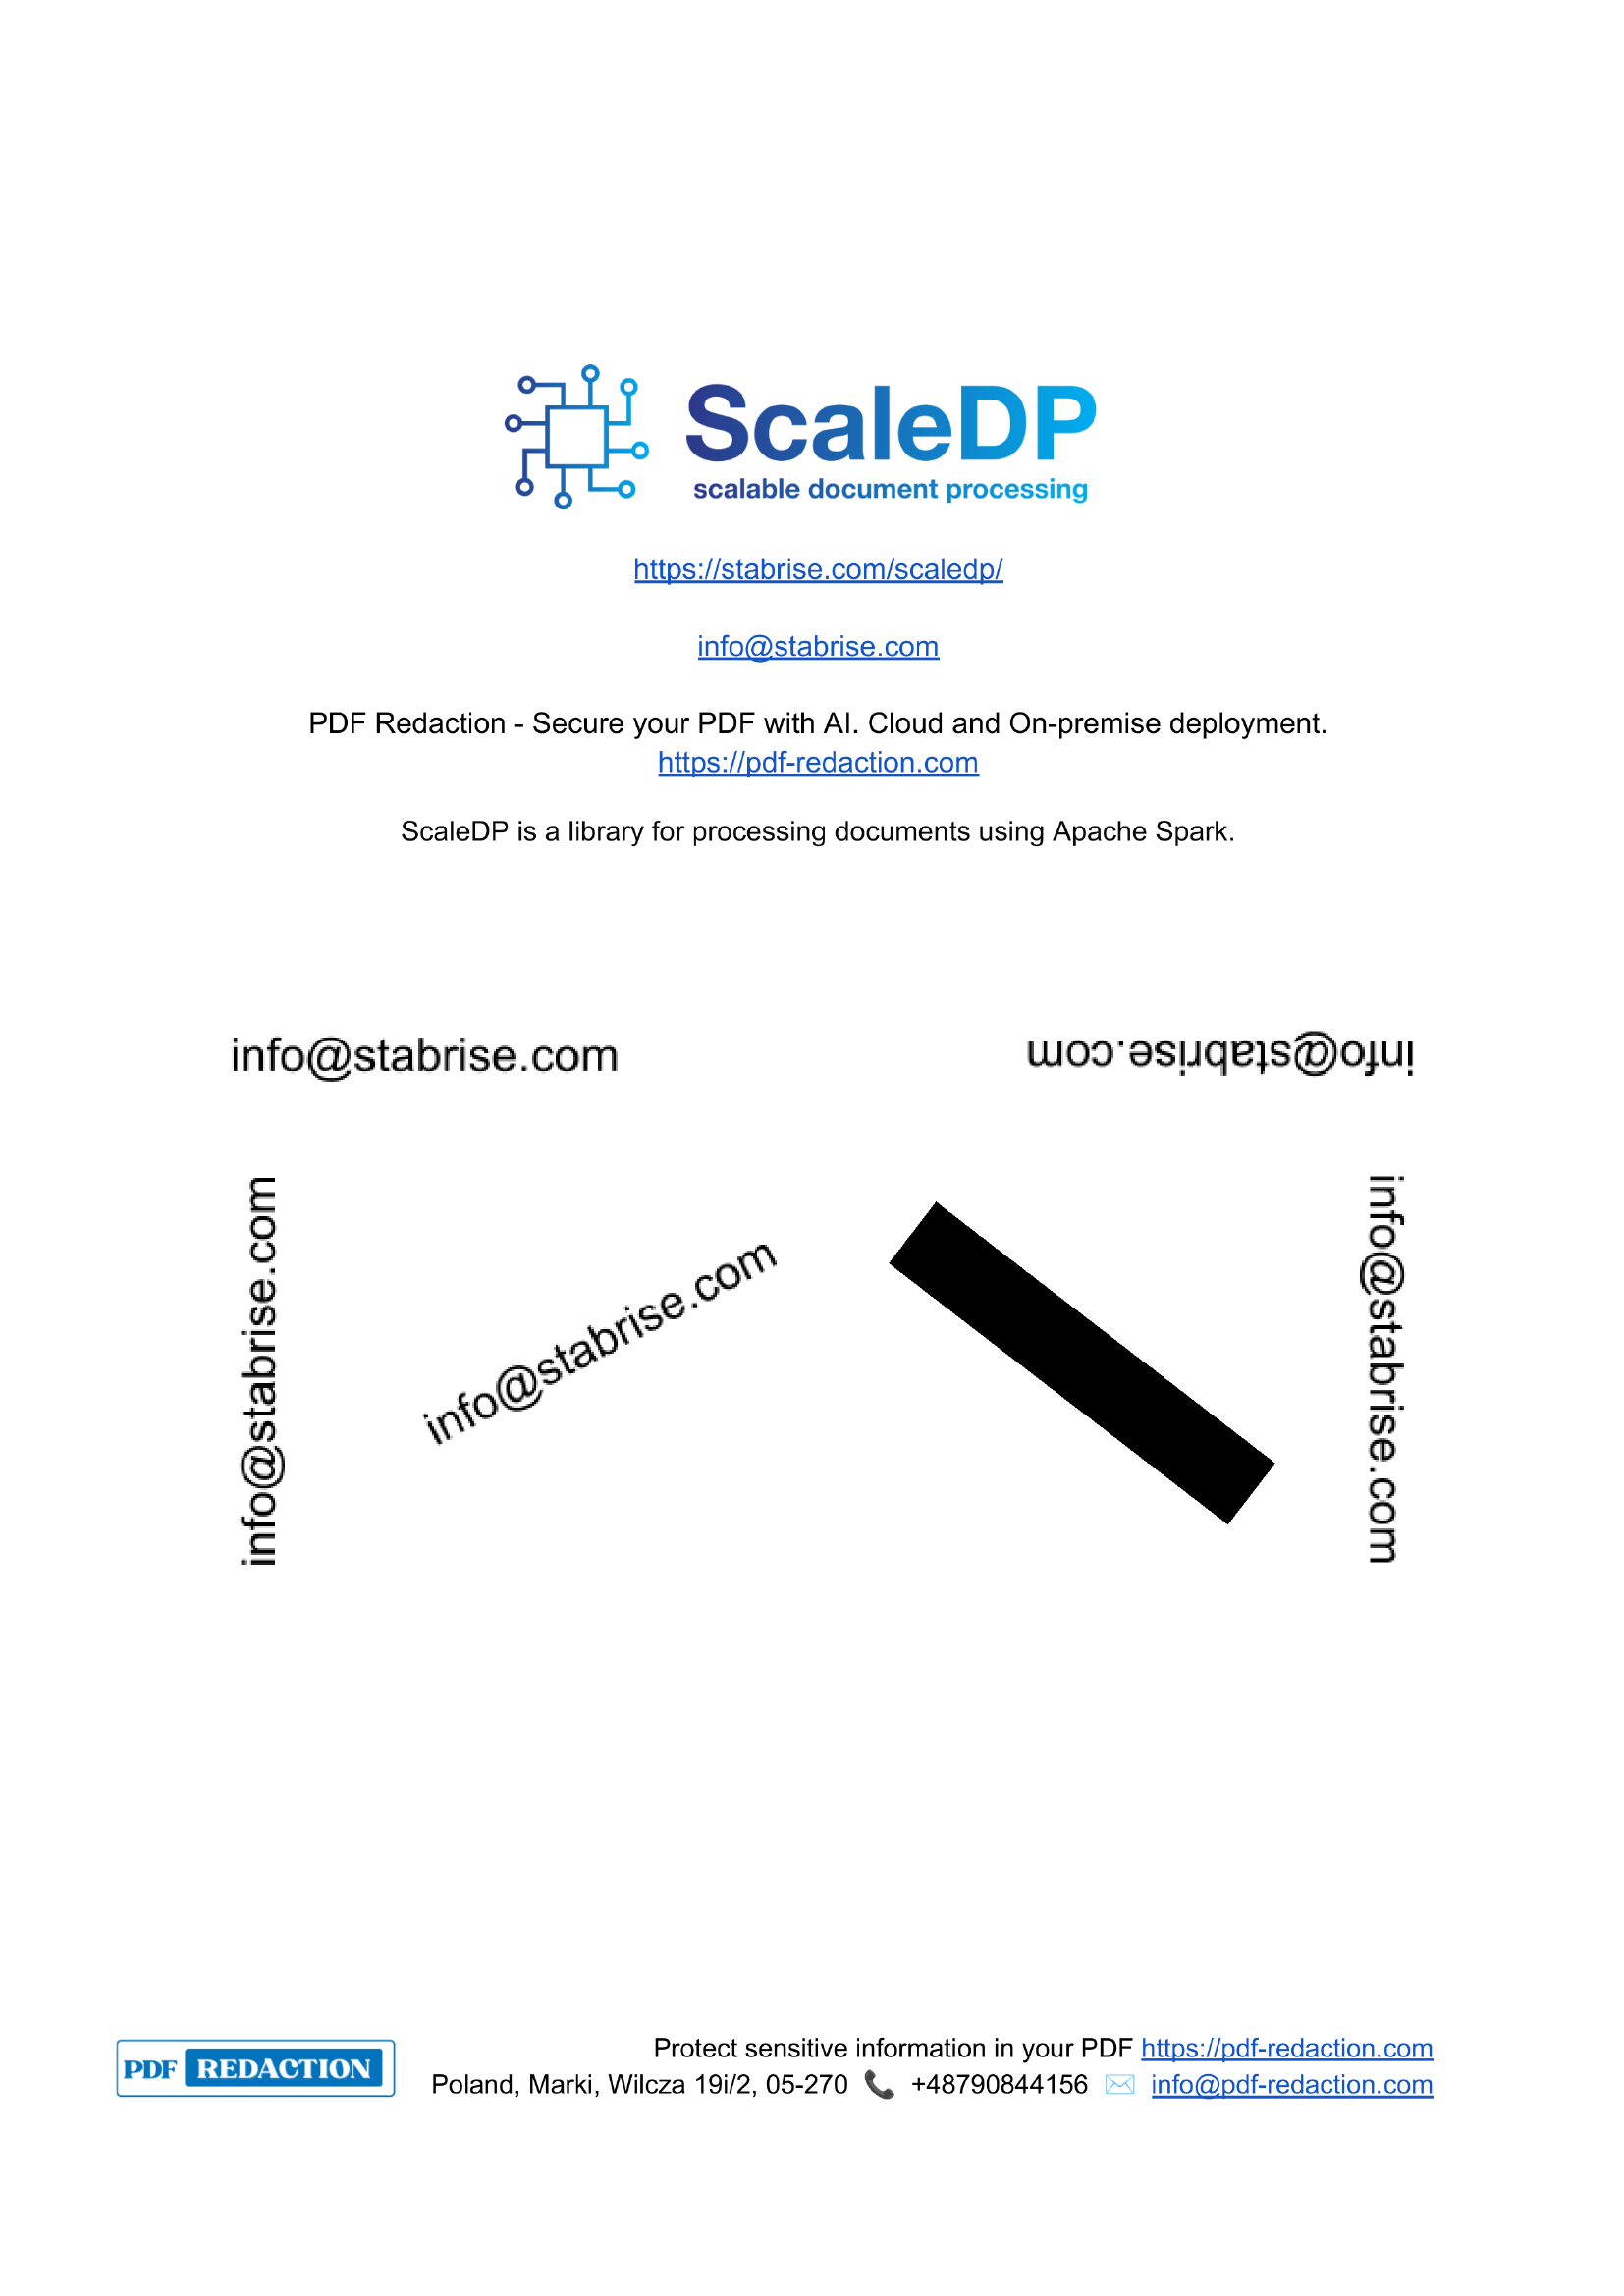

In [6]:
display_pdf(output_file_path)